# E-commerce Sales & Profitability Analysis

## Project Overview

This project analyzes 5,000 e-commerce orders to evaluate **sales performance, profitability, product and category performance, regional trends, discount behavior, payment patterns, and low-margin orders**.

The goal is to identify actionable patterns that can help a business improve **revenue growth, profitability, pricing decisions, inventory planning, and regional strategy**.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset
- **5,000 orders**
- **14 original columns**
- **10 product categories**
- **4 regions**
- **5 payment methods**

### Analysis Period
**October 4, 2023 – October 3, 2025**

## 1. Load & Understand the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')

print('Shape:', df.shape)
df.head(10)

Shape: (5000, 14)


,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.60,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.00,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.20,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.00,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.30,9050.04,Debit Card
5,10006,2025-04-06,Vardaniya Jayaraman,West,Pune,Furniture,Chair,Chair Assumenda,5,40287,15,171219.75,23722.84,Credit Card
6,10007,2023-10-13,Drishya Khare,West,Mumbai,Clothing,Accessories,Accessories Minima,2,3636,5,6908.40,680.26,Debit Card
7,10008,2025-08-17,Misha Dua,North,Lucknow,Books,Biography,Biography Vel,1,15885,10,14296.50,1289.03,Debit Card
8,10009,2025-03-07,Arhaan Vala,North,Jaipur,Groceries,Spices,Spices Expedita,1,40834,20,32667.20,3700.89,Credit Card
9,10010,2024-12-02,Lavanya Hayer,West,Goa,Kitchen,Juicer,Juicer Voluptatibus,2,16686,15,28366.20,5703.09,UPI


## Dataset Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   str    
 2   Customer Name  5000 non-null   str    
 3   Region         5000 non-null   str    
 4   City           5000 non-null   str    
 5   Category       5000 non-null   str    
 6   Sub-Category   5000 non-null   str    
 7   Product Name   5000 non-null   str    
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 547.0 KB


In [3]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [8]:
print('Nulls per column:', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nDuplicate Order IDs:', df['Order ID'].duplicated().sum())
print('\nUnique Order IDs:', df['Order ID'].nunique())
print('\nRegions:', df['Region'].unique())
print('\nCategories:', df['Category'].unique())
print('\nPayment Modes:', df['Payment Mode'].unique())

Nulls per column: Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

Duplicate rows: 0

Duplicate Order IDs: 0

Unique Order IDs: 5000

Regions: <StringArray>
['South', 'North', 'East', 'West']
Length: 4, dtype: str

Categories: <StringArray>
[      'Books',   'Groceries',     'Kitchen',    'Clothing',   'Furniture',
      'Beauty',  'Home Decor', 'Electronics',      'Sports',        'Toys']
Length: 10, dtype: str

Payment Modes: <StringArray>
['Debit Card', 'Credit Card', 'UPI', 'Net Banking', 'COD']
Length: 5, dtype: str


In [9]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Negative Profit:", (df['Profit'] < 0).sum())
print(
    "Invalid discounts:",
    ((df['Discount'] < 0) | (df['Discount'] > 100)).sum()
)

Negative Sales: 0
Negative Quantity: 0
Negative Profit: 0
Invalid discounts: 0


### Data Quality Investigation

- No **null or missing values** were found across the dataset.
- No **completely duplicated rows** were identified.
- `Order ID` contains **5,000 unique values**, matching the 5,000 records.
- No negative **Sales, Quantity, or Profit** values were found.
- All discount values fall within the expected **0–100%** range.
- The `Order Date` column was stored as a string and requires conversion to `datetime` for time-based analysis.
- The remaining data types are appropriate for the current analysis.

## 2. Data Preparation

The dataset required minimal cleaning. The `Order Date` column was converted to `datetime`, and helper columns were created for monthly trend and profitability analysis.

In [13]:
# Convert order date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Helper columns
df['Month'] = df['Order Date'].dt.to_period('M')
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

df[['Order Date', 'Month', 'Sales', 'Profit', 'Profit Margin %']].head()

,Order Date,Month,Sales,Profit,Profit Margin %
0,2024-10-19,2024-10,68958.6,10525.09,15.262911
1,2025-08-30,2025-08,33732.0,6299.66,18.675620
2,2023-11-04,2023-11,207603.2,19850.27,9.561640
3,2025-05-23,2025-05,158610.0,36311.02,22.893273
4,2025-01-19,2025-01,45033.3,9050.04,20.096329


### Derived Features

Two helper fields were created for the analysis:

- **Month:** Used to aggregate sales and profit over time.
- **Profit Margin %:** Calculated as `Profit / Sales × 100` to evaluate profitability relative to revenue.

### Executive Summary

In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = df['Sales'].mean()

overall_margin = (
    total_profit / total_sales * 100
)

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)
print("Overall Profit Margin:", overall_margin)

Total Sales: 533666024.35
Total Profit: 79708734.91
Total Orders: 5000
Average Order Value: 106733.20487
Overall Profit Margin: 14.936070739576207


### Executive Summary

Across 5,000 orders recorded between October 4, 2023 and October 3, 2025, the business generated approximately **₹533.67M in sales** and **₹79.71M in profit**, with an average order value of approximately **₹106,733** and an overall profit margin of **14.94%**.

The analysis shows meaningful differences in performance across **categories, regions, products, and discount levels**, providing several opportunities for more targeted pricing, inventory, and marketing decisions.

## 3. Business Questions

1. How have sales and profit trended month-over-month, and are there recurring monthly patterns?
2. Which categories drive the most sales vs. the most profit — and where do they diverge?
3. Which region performs best, and does regional performance vary by category?
4. Is discount level associated with profit margin, and does the relationship vary across discount brackets?
5. Which payment mode is most used, and how does average order value differ by mode?
6. Are there unusually low-margin orders worth flagging for further investigation?

### 3.1 Monthly Sales & Profit Trend
**Question:** How have sales and profit changed over the analysis period? Are there recurring monthly patterns?

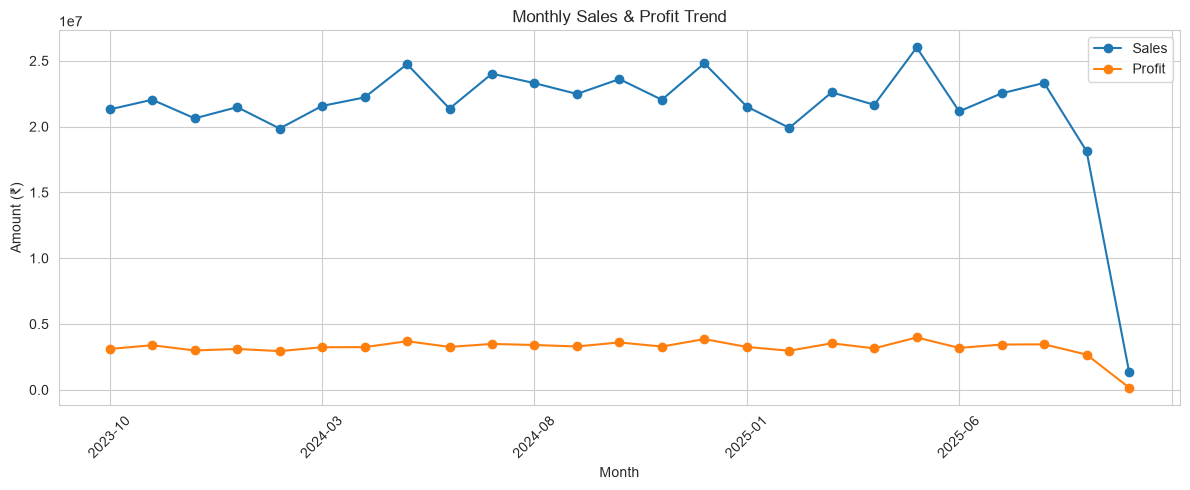

In [14]:
monthly = df.groupby('Month')[['Sales', 'Profit']].sum()
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, marker='o')
plt.title('Monthly Sales & Profit Trend')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Seasonal Sales & Profit Patterns

- Sales and profit show noticeable monthly variation, with **November and April–May** representing important high-sales periods.
- Peak monthly sales exceed approximately **₹25M**, making these periods important for inventory and marketing planning.
- Higher-sales months also generate higher absolute profit, but profit margin varies across months, indicating that revenue growth does not necessarily translate into proportional margin improvement.
- The dataset alone does not establish the cause of these seasonal peaks. Promotional calendars, holiday events, and marketing-spend data would be required to determine whether the increases are driven by specific campaigns or seasonal events.

### 3.2 Category performance — sales vs. profit
**Question:** Which categories drive the most sales vs. the most profit, and where do they diverge?

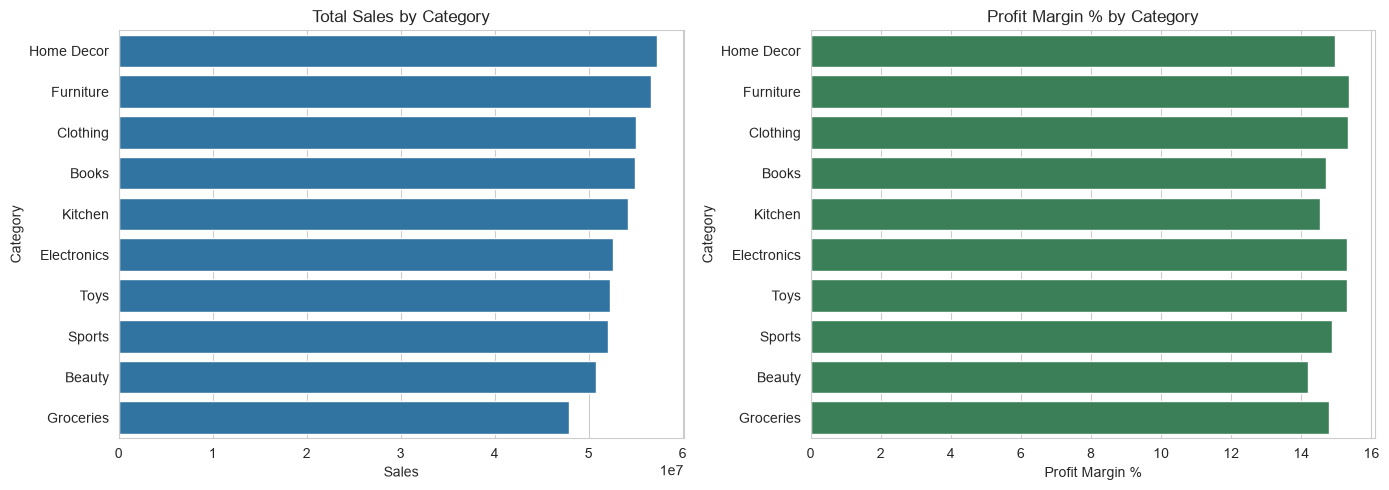

,Sales,Profit,Profit Margin %
Category,,,
Home Decor,57233222.35,8556846.94,14.950839
Furniture,56647187.90,8693087.03,15.346017
Clothing,55053908.30,8445750.29,15.340873
Books,54932643.00,8076273.29,14.702139
Kitchen,54227902.30,7879573.29,14.530478
Electronics,52587883.95,8042133.88,15.292750
Toys,52227366.45,7986871.44,15.292503
Sports,52069397.25,7739430.04,14.863683
Beauty,50803409.70,7213436.07,14.198724


In [15]:
cat_perf = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
cat_perf['Profit Margin %'] = (cat_perf['Profit'] / cat_perf['Sales']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=cat_perf['Sales'], y=cat_perf.index, ax=axes[0])
axes[0].set_title('Total Sales by Category')
sns.barplot(x=cat_perf['Profit Margin %'], y=cat_perf.index, ax=axes[1], color='seagreen')
axes[1].set_title('Profit Margin % by Category')
plt.tight_layout()
plt.show()

cat_perf

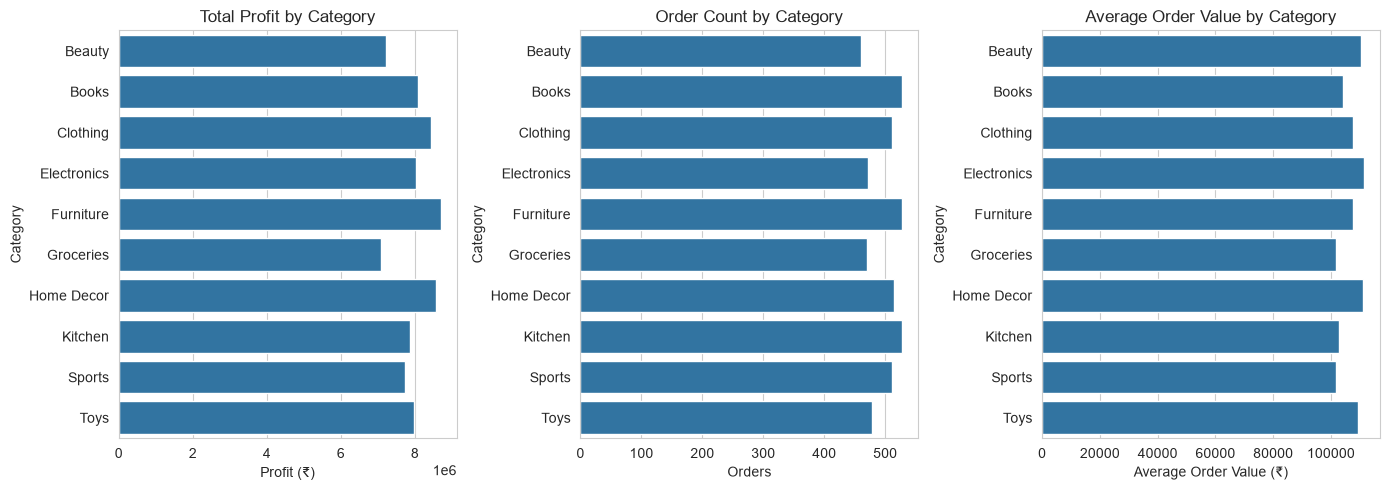

,Total_Sales,Total_Profit,Orders,Avg_Order_Value,Profit Margin %
Category,,,,,
Beauty,50803409.70,7213436.07,460,110442.195000,14.198724
Books,54932643.00,8076273.29,528,104039.096591,14.702139
Clothing,55053908.30,8445750.29,511,107737.589628,15.340873
Electronics,52587883.95,8042133.88,472,111415.008369,15.292750
Furniture,56647187.90,8693087.03,527,107489.920114,15.346017
Groceries,47883103.15,7075332.64,470,101878.942872,14.776262
Home Decor,57233222.35,8556846.94,515,111132.470583,14.950839
Kitchen,54227902.30,7879573.29,528,102704.360417,14.530478
Sports,52069397.25,7739430.04,511,101897.059198,14.863683


In [16]:
category_performance = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean')
)

category_performance['Profit Margin %'] = (
    category_performance['Total_Profit'] / category_performance['Total_Sales']
) * 100

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

sns.barplot(x=category_performance['Total_Profit'], y=category_performance.index, ax=ax1)
ax1.set_title('Total Profit by Category')
ax1.set_xlabel('Profit (₹)')

sns.barplot(x=category_performance['Orders'], y=category_performance.index, ax=ax2)
ax2.set_title('Order Count by Category')
ax2.set_xlabel('Orders')

sns.barplot(x=category_performance['Avg_Order_Value'], y=category_performance.index, ax=ax3)
ax3.set_title('Average Order Value by Category')
ax3.set_xlabel('Average Order Value (₹)')

plt.tight_layout()
plt.show()
category_performance

### Category Performance Insights

- **Home Decor** generates the highest total sales at approximately **₹57.23M**.
- **Furniture** generates the highest total profit at approximately **₹8.69M** and maintains a strong profit margin of about **15.35%**.
- **Groceries** has the lowest total sales among the 10 categories at approximately **₹47.88M**.
- **Beauty** records the lowest profit margin at approximately **14.20%**, indicating comparatively weaker profitability despite generating more than ₹50M in sales.
- **Electronics** has the highest average order value among the categories, suggesting that its typical order generates relatively higher revenue.
- The difference between category sales leadership and profit leadership shows why both **revenue and profitability** should be considered when evaluating category performance.

### 3.3 Regional performance
**Question:** Which region performs best, and does regional performance vary by category?

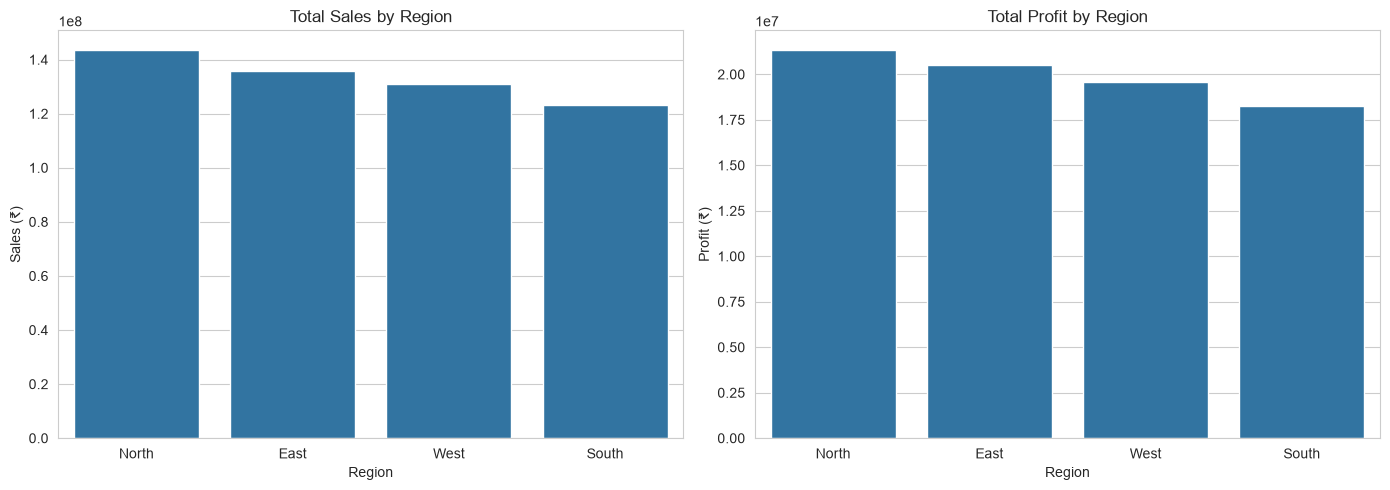

,Sales,Profit,Profit Margin %
Region,,,
North,1.435782e+08,21343004.33,14.865068
East,1.358116e+08,20532558.12,15.118408
West,1.310460e+08,19580123.14,14.941415
South,1.232302e+08,18253049.32,14.812160


In [17]:
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
region_perf['Profit Margin %'] = (region_perf['Profit'] / region_perf['Sales']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=region_perf.index, y=region_perf['Sales'], ax=axes[0])
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales (₹)')

sns.barplot(x=region_perf.index, y=region_perf['Profit'], ax=axes[1])
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit (₹)')

plt.tight_layout()
plt.show()
region_perf

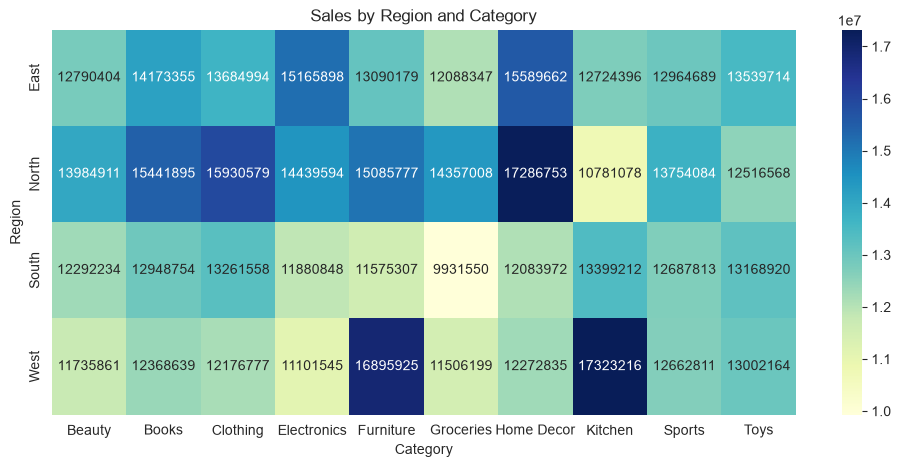

Category,Beauty,Books,Clothing,Electronics,Furniture,Groceries,Home Decor,Kitchen,Sports,Toys
Region,,,,,,,,,,
East,12790403.80,14173354.8,13684994.15,15165897.55,13090179.45,12088346.60,15589662.00,12724395.80,12964689.30,13539714.50
North,13984910.85,15441895.3,15930578.90,14439593.55,15085776.75,14357007.65,17286752.95,10781078.15,13754083.95,12516568.05
South,12292234.10,12948754.3,13261557.80,11880847.80,11575306.65,9931549.50,12083972.05,13399212.00,12687812.90,13168919.85
West,11735860.95,12368638.6,12176777.45,11101545.05,16895925.05,11506199.40,12272835.35,17323216.35,12662811.10,13002164.05


In [18]:
# Region x Category heatmap
pivot = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales by Region and Category')
plt.show()

pivot

### Regional Performance Insights

- **North** is the strongest region, generating approximately **₹143.58M in sales and ₹21.34M in profit**.
- **South** records the lowest regional totals at approximately **₹123.23M in sales and ₹18.25M in profit**, making it a candidate for further investigation.
- **Home Decor in the North** achieves the highest sales among all region-category combinations at approximately **₹17.29M**.
- **Kitchen and Furniture in the West** are particularly strong, generating approximately **₹17.32M and ₹16.90M** in sales respectively.
- The North also shows strong demand for **Clothing and Books**, while the East shows strong demand for **Electronics and Toys**.
- **Groceries in the South** records the lowest sales among the region-category combinations at approximately **₹9.93M**.

### 3.4 Discount vs. Profit Margin
**Question:** Is discount level associated with profit margin, and does the relationship vary across discount brackets?

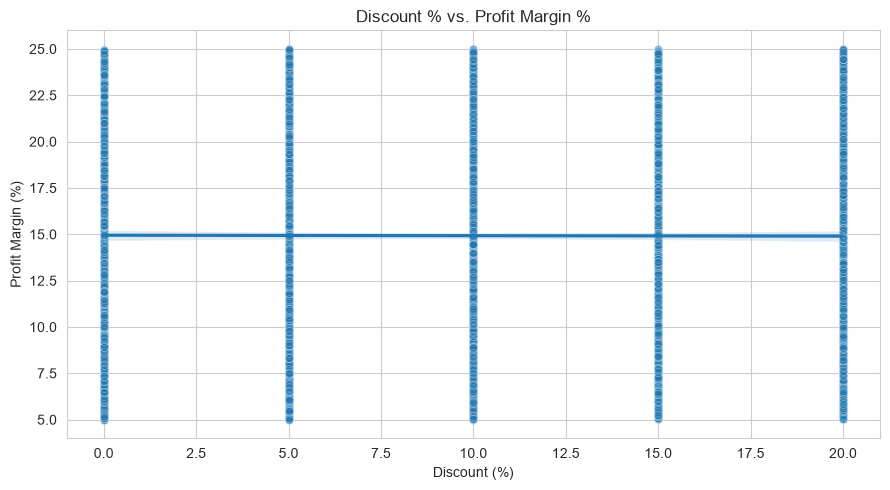

Correlation (Discount vs Profit Margin %): -0.003


In [19]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit Margin %', alpha=0.4)
sns.regplot(data=df, x='Discount', y='Profit Margin %', scatter=False)
plt.title('Discount % vs. Profit Margin %')
plt.xlabel('Discount (%)')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

print('Correlation (Discount vs Profit Margin %):', round(df['Discount'].corr(df['Profit Margin %']), 3))

#### Average margin by discount bracket

In [20]:
df['Discount Bracket'] = pd.cut(
    df['Discount'],
    bins=[-1, 5, 10, 15, 20],
    labels=['0-5%', '6-10%', '11-15%', '16-20%']
)

discount_analysis = df.groupby('Discount Bracket', observed=False).agg(
    Orders=('Order ID', 'nunique'),
    Avg_Profit_Margin=('Profit Margin %', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

discount_analysis

,Orders,Avg_Profit_Margin,Total_Sales,Total_Profit
Discount Bracket,,,,
0-5%,1976,14.920903,2.292022e+08,34325791.63
6-10%,1020,14.958635,1.105730e+08,16562542.62
11-15%,983,15.026556,9.728545e+07,14575951.61
16-20%,1021,14.796081,9.660545e+07,14244449.05


### 3.5 Top Product Performance

In [21]:
top_products = (
    df.groupby('Product Name')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Sales', ascending=False)
      .head(10)
)

top_products

,Sales,Profit,Orders
Product Name,,,
Headphones Accusantium,857184.20,141873.79,4
Spices Quibusdam,687651.25,96587.33,3
Accessories Repellendus,687083.30,131526.41,3
Bed Tenetur,670994.80,100233.59,3
Laptop Similique,666640.60,136751.80,3
Lamp Enim,665920.20,93638.94,4
Shampoo Commodi,659546.60,111950.64,3
Lamp Veritatis,652909.50,62922.96,3
Men's Wear Voluptatibus,649048.00,118300.59,2


### Product Performance Insights

- **Headphones Accusantium** is the top revenue-generating product in the top-10 list, with approximately **₹857K in sales**, **₹142K in profit**, and **4 orders**.
- **Laptop Similique** and **Accessories Repellendus** are also among the strongest profit contributors in the top-product group.
- **Men's Wear Voluptatibus** generated approximately **₹649K in sales from 2 orders**, resulting in a high average revenue per order; the small order count means this should be interpreted cautiously.
- **Lamp Veritatis** generated approximately **₹653K in sales but only ₹63K in profit**, making it a useful candidate for pricing or cost-structure review.

### 3.6 Payment Mode Behavior
**Question:** Which payment mode is most used, and how does average order value differ by mode?

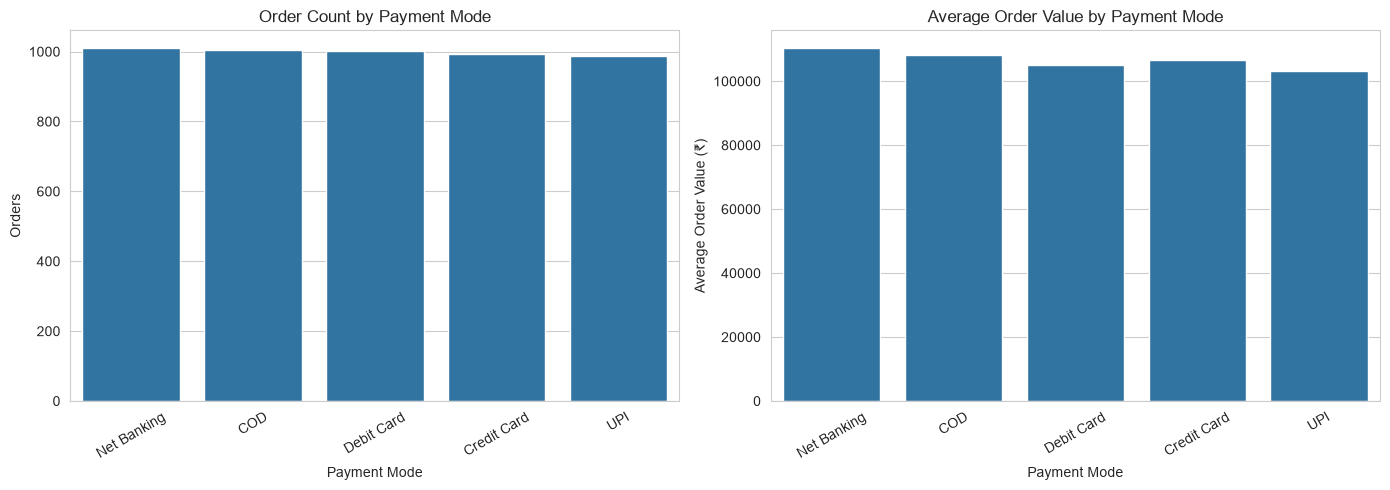

,Orders,Avg_Order_Value,Total_Sales,Profit
Payment Mode,,,,
Net Banking,1010,110361.897079,1.114655e+08,16964119.74
COD,1005,108339.697761,1.088814e+08,16575845.53
Debit Card,1003,105031.287787,1.053464e+08,15479323.07
Credit Card,994,106667.147787,1.060271e+08,15658639.35
UPI,988,103183.790992,1.019456e+08,15030807.22


In [22]:
pay_perf = df.groupby('Payment Mode').agg(
    Orders=('Order ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).sort_values('Orders', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=pay_perf.index, y=pay_perf['Orders'], ax=axes[0])
axes[0].set_title('Order Count by Payment Mode')
axes[0].set_xlabel('Payment Mode')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=pay_perf.index, y=pay_perf['Avg_Order_Value'], ax=axes[1])
axes[1].set_title('Average Order Value by Payment Mode')
axes[1].set_xlabel('Payment Mode')
axes[1].set_ylabel('Average Order Value (₹)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
pay_perf

### Payment Mode Insights

- Payment activity is relatively evenly distributed across the five payment methods, with order volumes ranging from approximately **988 to 1,010 orders**.
- **Net Banking** has the highest order count and average order value in this dataset.
- **UPI** records the lowest average order value among the payment methods, but the differences are relatively small.
- Because payment-method differences are modest, payment mode does not appear to be a major performance driver based on this analysis alone.
- Further analysis would be required before introducing payment-specific incentives or strategic changes.

### 3.7 Low-Margin Orders & Outlier Check
**Question:** Are there unusually low-margin orders worth flagging for further investigation?

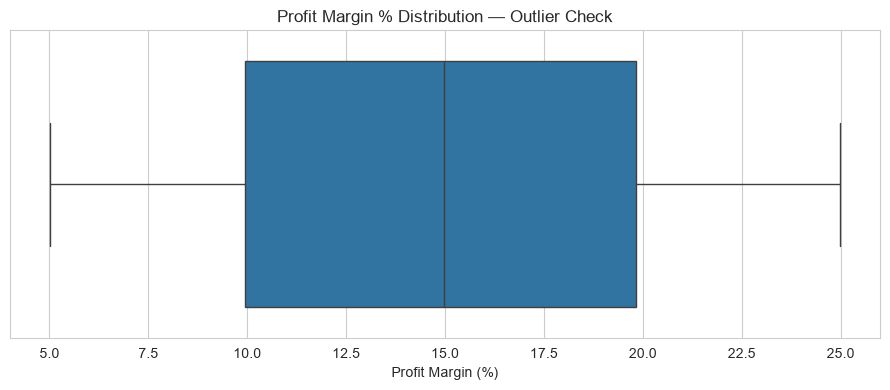

IQR lower bound: -4.89%
IQR upper bound: 34.64%
Statistical outliers: 0
Orders in the bottom 5% of profit margin: 250


,Order ID,Category,Region,Discount,Sales,Profit,Profit Margin %
2545,12546,Sports,West,10,67581.0,3379.92,5.001287
3700,13701,Beauty,North,0,156822.0,7844.50,5.002168
2203,12204,Clothing,North,0,43547.0,2179.90,5.005856
4968,14969,Beauty,North,5,54989.8,2753.58,5.007438
2513,12514,Toys,West,20,169068.8,8470.51,5.010096
3463,13464,Clothing,North,5,207242.5,10385.55,5.011303
1772,11773,Electronics,East,5,35421.7,1775.71,5.013057
1049,11050,Home Decor,West,5,20008.9,1003.16,5.013569
1237,11238,Home Decor,West,0,75422.0,3784.17,5.017329
647,10648,Books,North,15,101957.5,5116.45,5.018218


In [23]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df['Profit Margin %'])
plt.title('Profit Margin % Distribution — Outlier Check')
plt.xlabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

# IQR-based statistical outlier check
Q1 = df['Profit Margin %'].quantile(0.25)
Q3 = df['Profit Margin %'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Profit Margin %'] < lower_bound) |
    (df['Profit Margin %'] > upper_bound)
]

print(f'IQR lower bound: {lower_bound:.2f}%')
print(f'IQR upper bound: {upper_bound:.2f}%')
print(f'Statistical outliers: {len(outliers)}')

# Business-risk segment: bottom 5% of profit margins
low_margin = df[df['Profit Margin %'] < df['Profit Margin %'].quantile(0.05)]
print(f'Orders in the bottom 5% of profit margin: {len(low_margin)}')

low_margin[['Order ID', 'Category', 'Region', 'Discount', 'Sales', 'Profit', 'Profit Margin %']].sort_values('Profit Margin %').head(10)

### Profit Margin & Low-Margin Order Insights

- Profit margins are concentrated within a relatively narrow range, with the middle 50% of orders falling approximately between **10% and 20%**.
- Statistical outliers should be identified using the **IQR method**, rather than simply assuming that values outside a visual range are outliers.
- Separately, the **bottom 5% of orders** are flagged as low-margin orders for business investigation.
- These orders are not necessarily statistical outliers; they are identified because their profitability is relatively weak compared with the rest of the dataset.
- Some low-margin orders occur even with **0% discount**, suggesting that discounting alone may not explain weaker profitability.

## 4. Key Findings Summary

1. **Sales and profit show recurring monthly peaks.** November and April–May record particularly strong sales activity, with peak monthly sales exceeding approximately **₹25M**, highlighting important periods for inventory and marketing planning.

2. **Revenue leadership and profit leadership differ by category.** Home Decor generates the highest sales at approximately **₹57.23M**, while Furniture generates the highest total profit at approximately **₹8.69M**. This demonstrates why category performance should be evaluated using both revenue and profitability.

3. **Regional performance is uneven.** The North is the strongest region, generating approximately **₹143.58M in sales and ₹21.34M in profit**, while the South records the lowest totals at approximately **₹123.23M in sales and ₹18.25M in profit**.

4. **Discount percentage shows almost no linear association with profit margin.** The correlation is approximately **-0.003**, while low-margin orders also occur at 0% discount. This suggests that product economics, pricing, or cost structure may deserve further investigation.

5. **Low-margin business-risk orders exist even when extreme statistical outliers may not.** The bottom 5% of orders were identified for further review, demonstrating that business-risk segments can exist without extreme statistical outliers.

## 5. Recommendations

### 1. Plan Around High-Demand Periods

Use the recurring November and April–May sales peaks to improve **inventory planning, campaign preparation, and operational capacity**. Additional marketing-calendar data should be used to determine the causes of these peaks before attributing them to specific campaigns or holidays.

### 2. Prioritise Profitable Categories and Regional Opportunities

- Maintain strong focus on **Furniture**, which leads total profit and has a strong profit margin.
- Continue monitoring **Home Decor**, which leads total sales.
- Investigate the weaker performance of **Groceries in the South**, particularly the low sales relative to other region-category combinations.
- Consider prioritising **Kitchen and Furniture** in the West region based on their strong regional sales performance.

### 3. Investigate Margin Drivers Beyond Discounts

The near-zero correlation between discount and profit margin indicates that discount percentage alone does not explain margin variation.

Further investigation should focus on:
- Product-level pricing
- Product cost
- Supplier costs
- Category economics
- Pricing strategy
- Promotional activity

### 4. Review Low-Margin Products and Orders

Flag the bottom 5% of profit-margin orders for further investigation and prioritise products that combine **high sales with comparatively weak profitability**. Products such as **Lamp Veritatis** can be reviewed for pricing, cost structure, or supplier economics before increasing their promotional exposure.

## 6. Limitations & Next Steps

This analysis is based only on historical order-level data. Several potential business drivers—such as product cost, supplier cost, marketing spend, promotional campaigns, inventory levels, customer acquisition cost, and customer retention—are not included.

Therefore, the findings identify **patterns and areas for investigation rather than causal relationships**.

### Recommended Next Analysis

If additional business data becomes available, the next stage should investigate:

- Product-level cost and margin drivers
- Marketing campaign performance
- Customer retention and repeat purchasing
- Inventory availability and stock-outs
- Regional demand relative to customer base
- Pricing and discount elasticity
- Customer lifetime value


## Client-Facing Summary

Analyzed **5,000 e-commerce orders** recorded between October 2023 and October 2025 across **10 product categories and 4 regions**, generating approximately **₹533.67M in sales and ₹79.71M in profit**.

The analysis found that **Home Decor leads total sales while Furniture generates the highest total profit**, and that the **North region is the strongest overall performer**. Monthly analysis also identified recurring high-sales periods around **November and April–May**.

Discount percentage showed **almost no linear relationship with profit margin**, while low-margin orders were also found at 0% discount. This suggests that profitability should be investigated beyond discounting alone.

### Recommended Next Steps

Prioritise inventory and marketing planning around high-demand periods, maintain focus on strong category and regional performers, and investigate the pricing and cost structures behind low-margin products and orders.